In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
readFname = '../../WPWP_GLORYS_data/equator_sst_u_ssh_mld_2014_2024.nc'

fullDS = xr.open_dataset(readFname)

In [5]:
daily_climatology = fullDS.groupby('time.dayofyear').mean('time')
daily_anomalies = fullDS.groupby('time.dayofyear') - daily_climatology

In [43]:
def freq_wavenumber_spectrum(
    da,
    time_dim="time",
    lon_dim="lon",
    detrend=True,
    apply_window=True,
):
    """
    Compute 2D frequency–wavenumber spectrum from a 2D xarray.DataArray.

    Parameters
    ----------
    da : xr.DataArray
        Input data with dimensions (time, lon) or similar.
    time_dim : str
        Name of the time dimension.
    lon_dim : str
        Name of the longitude (x) dimension.
    detrend : bool
        If True, remove the mean along both dimensions.
    apply_window : bool
        If True, apply 2D Hanning window to reduce spectral leakage.

    Returns
    -------
    spec : xr.DataArray
        2D power spectrum with dims (frequency, wavenumber).
        Frequency in cycles per day, wavenumber in cycles per degree.
    """

    # ------------------------------------------------------------------
    # 1. Ensure correct dimension order and drop NaNs
    # ------------------------------------------------------------------
    da = da.transpose(time_dim, lon_dim)
    #da = da.dropna(time_dim, how="any").dropna(lon_dim, how="any")

    time = da[time_dim].to_numpy()
    lon = da[lon_dim].to_numpy()
    
    Nt = time.size
    Nx = lon.size

    # ------------------------------------------------------------------
    # 2. Compute sampling intervals (assumes regular spacing)
    # ------------------------------------------------------------------
    # time spacing in days
    dt_days = (time[1] - time[0]) / np.timedelta64(1, "D")
    # lon spacing in degrees
    dx_deg = float(lon[1] - lon[0])

    # ------------------------------------------------------------------
    # 3. Get data as numpy array and preprocess
    # ------------------------------------------------------------------
    field = da.values.astype(float)

    # Optional detrending: remove overall mean
    if detrend:
        field = field - np.nanmean(field)

    # Optional windowing to reduce spectral leakage
    if apply_window:
        wt = np.hanning(Nt)[:, None]   # time window
        wx = np.hanning(Nx)[None, :]   # space window
        window = wt * wx
        field = field * window

    # ------------------------------------------------------------------
    # 4. 2D FFT and power spectrum
    # ------------------------------------------------------------------
    F = np.fft.fft2(field)
    # Shift zero frequency/wavenumber to center
    F_shift = np.fft.fftshift(F)

    power = np.abs(F_shift) ** 2

    # ------------------------------------------------------------------
    # 5. Frequency and wavenumber axes
    # ------------------------------------------------------------------
    # Frequency in cycles per day
    freq = np.fft.fftfreq(Nt, d=dt_days)         # unshifted
    freq = np.fft.fftshift(freq)                 # shifted

    # Zonal wavenumber in cycles per degree
    kx = np.fft.fftfreq(Nx, d=dx_deg)
    kx = np.fft.fftshift(kx)

    # Build xarray DataArray
    spec = xr.DataArray(
        power,
        coords={"frequency_cpd": freq, "k_lon_cycledeg": kx},
        dims=("frequency_cpd", "k_lon_cycledeg"),
        name="power_spectrum",
    )

    return spec


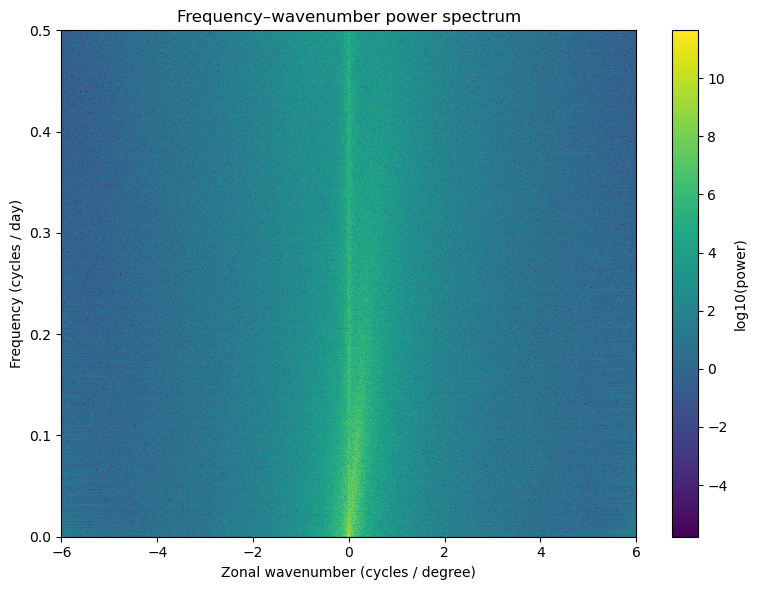

In [64]:
da = daily_anomalies['sst'].sel(longitude=slice(130,275))
da = da.interpolate_na(
    dim="longitude", method="linear"
).interpolate_na(
    dim="time", method="linear"
)

spec = freq_wavenumber_spectrum(da, time_dim="time", lon_dim="longitude")

# Optional: keep only positive frequencies
spec_pos = spec.sel(frequency_cpd=slice(0, None))

# ============================
# Simple plot
# ============================
plt.figure(figsize=(8, 6))
# log10 to see structure better
plt.pcolormesh(
    spec_pos["k_lon_cycledeg"],
    spec_pos["frequency_cpd"],
    np.log10(spec_pos + 1e-20),
    shading="auto",
)
# plt.xlim(-2,2)
# plt.ylim(0, 0.1)
plt.xlabel("Zonal wavenumber (cycles / degree)")
plt.ylabel("Frequency (cycles / day)")
plt.title("Frequency–wavenumber power spectrum")
plt.colorbar(label="log10(power)")
plt.tight_layout()
plt.show()


In [65]:
da

<xarray.DataArray 'sst' (time: 4011, longitude: 1741)> Size: 56MB
array([[-0.12238477, -0.15907357, -0.16596773, ..., -0.76194175,
        -0.77825528, -0.79663298],
       [-0.11106518, -0.13710024, -0.16254535, ..., -1.02542192,
        -1.0259546 , -1.02888438],
       [ 0.01338375, -0.00432808, -0.04236252, ..., -1.00025247,
        -0.97901159, -0.96363026],
       ...,
       [ 0.38919423,  0.35650058,  0.39929765, ..., -1.35661988,
        -1.38178933, -1.39537284],
       [ 0.45558031,  0.39551988,  0.43335449, ..., -1.57681925,
        -1.58161343, -1.58028171],
       [ 0.38253564,  0.312221  ,  0.37306943, ..., -1.72157686,
        -1.71165557, -1.69607449]], shape=(4011, 1741))
Coordinates:
  * time       (time) datetime64[ns] 32kB 2014-01-01T12:00:00 ... 2024-12-24
  * longitude  (longitude) float32 7kB 130.0 130.1 130.2 ... 274.8 274.9 275.0
    latitude   (time) float32 16kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    depth      (time) float32 16kB 0.494 0.494 0.494 0.494 ... 0.494 0.494 0.494
    dayofyear  (time) int64 32kB 1 2 3 4 5 6 7 8 ... 353 354 355 356 357 358 359

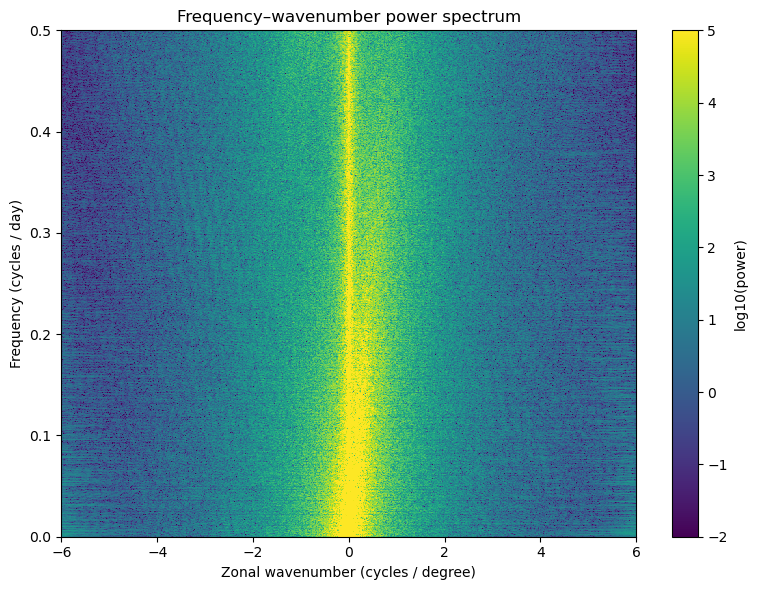

In [83]:
da = daily_anomalies['sst'].sel(longitude=slice(150,220))#.sel(time=slice('2014-01-01','2015-01-01'))
da = da.interpolate_na(
    dim="longitude", method="linear"
).interpolate_na(
    dim="time", method="linear"
)

spec = freq_wavenumber_spectrum(da, time_dim="time", lon_dim="longitude")

# Optional: keep only positive frequencies
spec_pos = spec.sel(frequency_cpd=slice(0, None))

# ============================
# Simple plot
# ============================
plt.figure(figsize=(8, 6))
# log10 to see structure better
plt.pcolormesh(
    spec_pos["k_lon_cycledeg"],
    spec_pos["frequency_cpd"],
    np.log10(spec_pos + 1e-20),
    shading="auto",
)
# plt.xlim(-2,2)
# plt.ylim(0, 0.1)
plt.clim(-2,5)
plt.xlabel("Zonal wavenumber (cycles / degree)")
plt.ylabel("Frequency (cycles / day)")
plt.title("Frequency–wavenumber power spectrum")
plt.colorbar(label="log10(power)")
plt.tight_layout()
plt.show()


In [36]:
da = fullDS['sst'].sel(longitude=slice(130,275))
da = da.interpolate_na(
    dim="longitude", method="linear"
)
np.sum(np.isnan(da.isel(time=0).to_numpy()))

np.int64(3482)

In [32]:
da

<xarray.DataArray 'sst' (time: 4011, longitude: 1801)> Size: 58MB
array([[29.71974852, 29.69191564, 29.68605394, ..., 25.85024567,
                nan,         nan],
       [29.73879207, 29.70876186, 29.69264218, ..., 25.88979766,
                nan,         nan],
       [29.78640094, 29.7724845 , 29.75013677, ..., 25.98794518,
                nan,         nan],
       ...,
       [30.39432965, 30.34232611, 30.3859225 , ..., 26.74089785,
                nan,         nan],
       [30.50199895, 30.41044343, 30.45697066, ..., 26.75554673,
                nan,         nan],
       [30.37308877, 30.27933591, 30.355538  , ..., 26.91375469,
                nan,         nan]], shape=(4011, 1801))
Coordinates:
  * time       (time) datetime64[ns] 32kB 2014-01-01T12:00:00 ... 2024-12-24
  * longitude  (longitude) float32 7kB 130.0 130.1 130.2 ... 279.8 279.9 280.0
    latitude   float32 4B ...
    depth      float32 4B ...
Attributes:
    long_name:      Temperature
    standard_name:  sea_water_potential_temperature
    units:          degrees_C
    unit_long:      Degrees Celsius
    valid_min:      -32197
    valid_max:      20067
    cell_methods:   area: mean